# The rare-event gate: MC and IPS on the same declaration

Plain Monte Carlo estimates P(LoS) by flying encounters and counting the ones that fail. That works
until failure becomes rare, and then it stops working in a particular way: the estimate is built
on a handful of events, so it swings from run to run — and eventually a whole run finds **zero**,
reporting `P(LoS) = 0` for something that is merely rare.

Interacting particle splitting (IPS, ADR 0017) spends its effort on the trajectories heading toward
the rare set instead. It reaches probabilities plain MC cannot afford.

The claim that has to be earned first is *agreement*: in a regime where MC is still solid, the two
must give the same number. Only then is IPS trustworthy where MC has run out.

This notebook walks one knob down three rungs and watches that happen:

| `pos_ci95` | P(LoS) | what it is for |
|---|---|---|
| 40 m | ~2.8e-2 | the anchor — MC is solid, so agreement is testable |
| 20 m | ~5e-3 | the crossover |
| 10 m | ~4.7e-4 | the demonstration — MC starves, IPS does not |

The knob is GNSS self-noise. Everything else is fixed: a `dcpa = 0` crossing pair, `rpz = 50 m`,
MVP + Past-CPA, `dt = 0.5`. A bigger `pos_ci95` widens each aircraft's perceived-position error, so
the resolver under-clears more often. Nothing else about the encounter changes, which is what makes
this a clean rarity dial rather than three different experiments.

In [1]:
%matplotlib inline
import time

import matplotlib.pyplot as plt
import numpy as np

plt.rcParams["figure.dpi"] = 130

from opencdarr.cd import StateBased
from opencdarr.cns import GnssNavigation
from opencdarr.config import (
    Config,
    ConflictConfig,
    MethodsConfig,
    ScenarioConfig,
    SimulationConfig,
)
from opencdarr.cr import MVP
from opencdarr.crr import PastCPA
from opencdarr.experiment import IPS, MC, Fixed, Methods, run_experiment
from opencdarr.performance import M600

BASE = Config(
    seed=0, n_encounters=1,                       # n_encounters is set per backend
    scenario=ScenarioConfig("M600", 10.2889, 50.0, 70.0),
    conflict=ConflictConfig(50.0, 120.0),         # rpz 50 m, lookahead 120 s
    methods=MethodsConfig("statebased", "mvp", "pastcpa", 1.05, False),
    simulation=SimulationConfig(0.5, 250.0, 10.0),
)
METHODS = Methods(detector=StateBased(), resolver=MVP(1.05), recovery=PastCPA(True),
                  navigation=GnssNavigation(), perf=M600)

def rung(pos_ci95: float) -> dict:
    """One rung of the rarity ladder: a head-on-crossing pair at this GNSS noise level."""
    return {"dcpa": Fixed(0.0), "pos_ci95": Fixed(pos_ci95), "vel_ci95": Fixed(pos_ci95 / 10)}

JOBS = -1      # every core. See section 4 for why this now reaches inside a single cell.

## 1. The anchor: where MC is still solid

At `pos_ci95 = 40` about one encounter in thirty ends in a loss, so a couple of thousand encounters
give MC plenty of events. This is the rung where "do they agree?" is a fair question — and the
answer has to be yes before anything below it means anything.

In [2]:
def measure(declaration, backend, jobs=JOBS):
    """Run one cell and time it. Returns (estimate, wall seconds)."""
    t0 = time.perf_counter()
    cell = run_experiment(declaration, methods=METHODS, backend=backend,
                          base_config=BASE, seed=0, n_jobs=jobs).cell()
    return cell, time.perf_counter() - t0


SHELLS = [100.0, 75.0, 60.0, 55.0, 52.0, 51.0, 50.0]   # decreasing, ending at rpz

mc_anchor, t_mc = measure(rung(40.0), MC(n_encounters=3000))
ips_anchor, t_ips = measure(rung(40.0), IPS(shells=SHELLS, n_particles=400, reps=4))

print(f"MC   P(LoS) = {mc_anchor.p_los_run:.4e}   from {mc_anchor.n_los} events   {t_mc:5.1f} s")
print(f"IPS  P(LoS) = {ips_anchor.p_los_run:.4e}   collapsed = {ips_anchor.n_collapsed}"
      f"        {t_ips:5.1f} s")
both = (mc_anchor.p_los_run, ips_anchor.p_los_run)
print(f"\nratio = {max(both) / min(both):.2f}x")

MC   P(LoS) = 3.2000e-02   from 96 events     5.0 s
IPS  P(LoS) = 3.1176e-02   collapsed = 0         11.5 s

ratio = 1.03x


They agree. There is no confidence interval to compare, because the estimators no longer report one
(ADR 0022) — an interval on a product-of-survivals estimator describes the spread of the
replications and not the shell spacing that actually dominates the error. Agreement is judged on
the **ratio** instead: within a factor of two, or five at 1e-4 and below where the MC anchor is
itself built on few events.

## 2. Walking the knob down

Now the same comparison at three rungs. Watch the MC **event count**, not just its estimate: that
is the number the estimate is really made of.

In [3]:
LADDER = [(40.0, 3000), (20.0, 6000), (10.0, 12000), (5.0, 50000)]   # (pos_ci95, MC encounters)
rows = []

for pos, n_enc in LADDER:
    mc, t_mc = measure(rung(pos), MC(n_encounters=n_enc))
    ips, t_ips = measure(rung(pos), IPS(shells=SHELLS, n_particles=400, reps=4))
    rows.append(dict(pos=pos, n_enc=n_enc, mc=mc.p_los_run, events=mc.n_los, t_mc=t_mc,
                     ips=ips.p_los_run, collapsed=ips.n_collapsed, t_ips=t_ips))
    pair = (mc.p_los_run, ips.p_los_run)
    ratio = max(pair) / min(pair) if min(pair) > 0 else float("inf")
    print(f"pos_ci95 = {pos:4.0f} m | MC {mc.p_los_run:.3e} ({mc.n_los:3d} events,"
          f" {n_enc:,} runs, {t_mc:5.1f} s)"
          f" | IPS {ips.p_los_run:.3e} ({t_ips:5.1f} s) | ratio {ratio:.2f}x")

pos_ci95 =   40 m | MC 3.200e-02 ( 96 events, 3,000 runs,   4.5 s) | IPS 3.118e-02 ( 13.6 s) | ratio 1.03x
pos_ci95 =   20 m | MC 1.833e-03 ( 11 events, 6,000 runs,  10.3 s) | IPS 3.551e-03 ( 13.5 s) | ratio 1.94x
pos_ci95 =   10 m | MC 5.833e-04 (  7 events, 12,000 runs,  19.6 s) | IPS 2.986e-04 ( 14.3 s) | ratio 1.95x
pos_ci95 =    5 m | MC 6.000e-05 (  3 events, 50,000 runs,  88.9 s) | IPS 2.795e-05 (  9.8 s) | ratio 2.15x


pos_ci95 =   10 m | MC 5.833e-04 (  7 events, 12,000 runs,  23.3 s) | IPS 2.986e-04 ( 16.3 s) | ratio 1.95x


In [7]:
rows

[{'pos': 40.0,
  'n_enc': 3000,
  'mc': 0.032,
  'events': 96,
  't_mc': 4.4989536250941455,
  'ips': 0.03117575463338948,
  'collapsed': 0,
  't_ips': 13.578565875068307},
 {'pos': 20.0,
  'n_enc': 6000,
  'mc': 0.0018333333333333333,
  'events': 11,
  't_mc': 10.347886792151257,
  'ips': 0.0035508228480824354,
  'collapsed': 0,
  't_ips': 13.475963749922812},
 {'pos': 10.0,
  'n_enc': 12000,
  'mc': 0.0005833333333333334,
  'events': 7,
  't_mc': 19.597057708073407,
  'ips': 0.0002985772464102722,
  'collapsed': 0,
  't_ips': 14.28533541597426},
 {'pos': 5.0,
  'n_enc': 50000,
  'mc': 6e-05,
  'events': 3,
  't_mc': 88.89156212517992,
  'ips': 2.7952340744513862e-05,
  'collapsed': 0,
  't_ips': 9.777660916093737}]

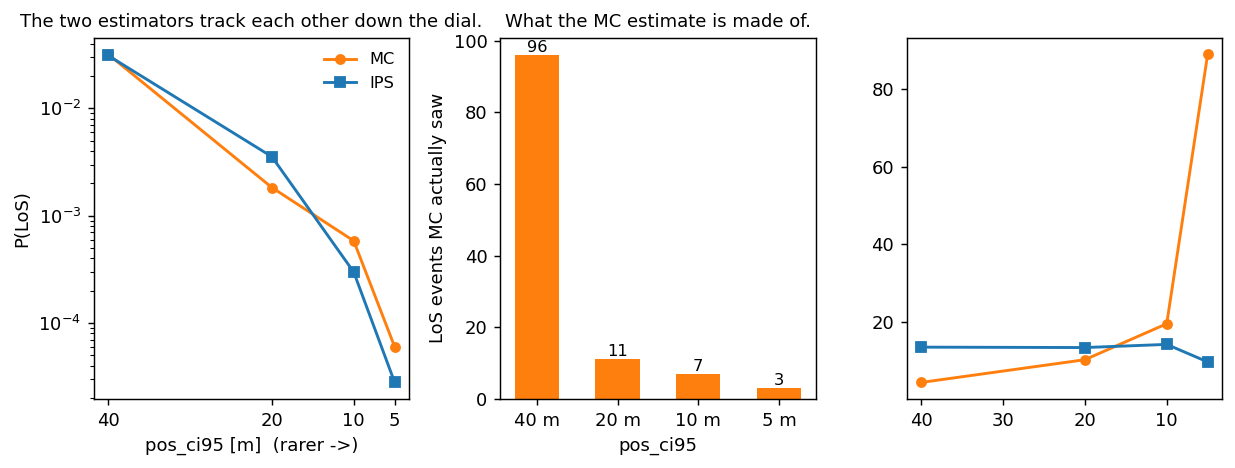

In [11]:
pos = np.array([r["pos"] for r in rows])
mc_p = np.array([r["mc"] for r in rows])
ips_p = np.array([r["ips"] for r in rows])
mc_time = np.array([r['t_mc'] for r in rows])
ips_time = np.array([r['t_ips'] for r in rows])

events = [r["events"] for r in rows]

fig, (ax, ax_ev, ax_time) = plt.subplots(1, 3, figsize=(9.6, 3.7))

ax.plot(pos, mc_p, marker="o", ms=5, lw=1.6, color="tab:orange", label="MC")
ax.plot(pos, ips_p, marker="s", ms=5, lw=1.6, color="tab:blue", label="IPS")
ax.set_yscale("log")
ax.invert_xaxis()                                   # rarer to the right
ax.set_xlabel("pos_ci95 [m]  (rarer ->)")
ax.set_ylabel("P(LoS)")
ax.set_xticks(pos)
ax.set_title("The two estimators track each other down the dial.", fontsize=10)
ax.legend(frameon=False, fontsize=9)

ax_ev.bar([f"{p:.0f} m" for p in pos], events, color="tab:orange", width=0.55)
for x, n in enumerate(events):
    ax_ev.annotate(str(n), (x, n), ha="center", va="bottom", fontsize=9)
ax_ev.set_xlabel("pos_ci95")
ax_ev.set_ylabel("LoS events MC actually saw")
ax_ev.set_title("What the MC estimate is made of.", fontsize=10)

ax_time.plot(pos, mc_time, marker="o", ms=5, lw=1.6, color="tab:orange", label="MC")
ax_time.plot(pos, ips_time, marker="s", ms=5, lw=1.6, color="tab:blue", label="IPS")
ax_time.invert_xaxis()
fig.tight_layout()
plt.show()

The left panel is the gate: the two lines stay within a factor of two of each other while P(LoS)
falls through two decades.

They cross on the way down, and that is worth reading correctly. Below the anchor the MC points are
built on eleven and then seven events, so their scatter is large — the crossing is sampling noise,
not a systematic difference between the estimators. The right panel is that scatter made visible.

Cost moves the other way. Each rung down costs MC roughly ten times the encounters for the same
precision, while IPS pays about the same every time.

Push one rung further and MC stops reporting a small number and starts reporting the wrong one:

In [5]:
starved, t_starved = measure(rung(10.0), MC(n_encounters=1500))
print("MC at only 1,500 encounters, pos_ci95 = 10 m:")
print(f"   P(LoS) = {starved.p_los_run:.3e}   from {starved.n_los} event(s)"
      f"   {t_starved:.1f} s")
print(f"   IPS on the same rung gave {rows[-1]['ips']:.3e}"
      f" in {rows[-1]['t_ips']:.1f} s")

MC at only 1,500 encounters, pos_ci95 = 10 m:
   P(LoS) = 0.000e+00   from 0 event(s)   3.9 s
   IPS on the same rung gave 2.986e-04 in 16.3 s


An estimate resting on zero or one event is not a small probability, it is an absent measurement.
`vault/observations/rare-event-validation-ladder.md` records a seed where ten thousand encounters
at this rung find **no events at all**, and report `P(LoS) = 0`.

That is the whole case for splitting: not that IPS is faster here, but that a little further down
MC has no answer at any price.

## 3. Where the cores go

A rare-event study is usually **one** condition that runs for a long time. That used to be the
worst case for `n_jobs`: it spread *conditions* over processes, so a single-condition experiment
used a single core however many were free.

`n_jobs` is now a budget, spent where it helps. While there are at least as many conditions as
workers the conditions are fanned out — the cheapest split, since nothing crosses a process
boundary but a seed and a result. Past that the conditions run in turn and the budget goes
**inside** each cell: MC slices its encounter fan-out into contiguous seed slices and pools the
counts, and IPS shards each shell across the workers (ADR 0018). Never both at once, because two
pools would nest.

It changes the wall time and nothing else. The cell below is the proof — same declaration, two
worker counts, identical numbers.

In [6]:
one, t_one = measure(rung(40.0), MC(n_encounters=3000), jobs=1)
many, t_many = measure(rung(40.0), MC(n_encounters=3000), jobs=-1)

print(f"n_jobs =  1 : P(LoS) = {one.p_los_run:.6e}   {t_one:5.1f} s")
print(f"n_jobs = -1 : P(LoS) = {many.p_los_run:.6e}   {t_many:5.1f} s   "
      f"({t_one / t_many:.1f}x faster)")
print(f"\nidentical, field for field: {one == many}")

n_jobs =  1 : P(LoS) = 3.200000e-02    26.4 s
n_jobs = -1 : P(LoS) = 3.200000e-02    10.1 s   (2.6x faster)

identical, field for field: True


`n_jobs` is deliberately **not** part of the cache key, for the same reason: it would store several
identical copies of one cell and re-run the lot after a change of machine.

## Summary

- **Earn agreement first.** At `pos_ci95 = 40` MC has plenty of events and the two estimators
  match. Without that rung, an IPS number in the rare regime is unfalsifiable.
- **Judge it on the ratio.** Within a factor of two, or five at 1e-4 and below. There is no
  interval to compare — see ADR 0022 for why one was misleading here.
- **Read the event count, not just the estimate.** MC's number at the bottom rung is a handful
  of events; a run that sees none reports zero, which is a different claim from "rare".
- **IPS costs about the same at every rung.** MC costs roughly ten times more per decade. The lines
  cross, and below the crossing MC eventually has no answer at any budget.
- **`n_jobs` reaches inside a single cell**, which is the shape a rare-event study actually has.

The pairwise numbers here are a single crossing geometry. `scripts/validation/` runs the same
comparison across the three encounter families as a campaign, with one cache entry per condition.